## TUGAS 5 KLASIFIKASI WITH REDUKSI SVD

Prio Budi Laksono

210411100177

Preprocessing hasil crawling data dari kompas.com

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import random

# Daftar user agents yang akan dirotasi
USER_AGENTS = [
    'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3',
    'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36',
    'Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:89.0) Gecko/20100101 Firefox/89.0',
]

# Fungsi untuk mengambil dan mem-parsing HTML dari URL
def get_soup(url):
    headers = {
        'User-Agent': random.choice(USER_AGENTS)
    }
    try:
        response = requests.get(url, headers=headers)
        if response.status_code == 200:
            return BeautifulSoup(response.text, 'html.parser')
        else:
            print(f"Error {response.status_code} saat mengambil {url}")
            return None
    except Exception as e:
        print(f"Error: {e}")
        return None

def get_article_details(detail_url, category_name):
    detail_soup = get_soup(detail_url)
    if detail_soup:
        # Ambil konten dari div dengan class 'read__content'
        content_div = detail_soup.find('div', class_='read__content')
        content = ' '.join([p.text for p in content_div.find_all('p')]) if content_div else 'Tidak ada isi berita'
        
        # Coba ambil tanggal dari div dengan class 'videoKG-date' terlebih dahulu
        date_tag = detail_soup.find('div', class_='videoKG-date')
        if not date_tag:
            # Jika tidak ditemukan, ambil dari div dengan class 'read__time'
            date_tag = detail_soup.find('div', class_='read__time')
        
        date = date_tag.text.strip().split('-')[-1].strip() if date_tag else 'Tidak ada tanggal'
        
        # Ambil judul artikel
        title_tag = detail_soup.find('h1')
        title = title_tag.text.strip() if title_tag else 'Tidak ada judul'
        
        return {
            'judul': title,
            'isi_berita': content,
            'tanggal': date,
            'kategori': category_name,
        }
    return None


# Fungsi untuk mendapatkan artikel dari suatu kategori
def get_articles(category_url, category_name, max_articles):
    articles = []
    page = 1
    while len(articles) < max_articles:
        url = f'{category_url}?page={page}'
        print(f"Mengambil: {url}")
        soup = get_soup(url)
        if soup is None:
            break
        article_list = soup.find_all('h3', class_='article__title')
        if not article_list:
            print(f"Tidak ada artikel ditemukan di halaman {page}.")
            break
        for article in article_list:
            if len(articles) >= max_articles:
                break
            title_tag = article.find('a')
            detail_url = title_tag['href'] if title_tag else None
            if detail_url:
                article_details = get_article_details(detail_url, category_name)
                if article_details:
                    articles.append(article_details)
        
        sleep_time = random.uniform(3, 6)
#         print(f"Menunggu selama {sleep_time:.2f} detik sebelum mengambil halaman berikutnya...")
        time.sleep(sleep_time)
        
        page += 1
    return articles

# URL Kategori Kompas
categories = {
    'Travel': 'https://www.kompas.com/tag/travel',
    'Timnas Indonesia': 'https://www.kompas.com/tag/timnas-indonesia',
}

max_articles=50

# Mengumpulkan semua data
all_articles = []
for category_name, category_url in categories.items():
    print(f"Menambang kategori {category_name}...")
    articles = get_articles(category_url, category_name, max_articles)
    all_articles.extend(articles)

# Simpan ke dalam DataFrame
df = pd.DataFrame(all_articles)

# Simpan ke dalam file CSV tanpa kolom 'url'
df.to_csv('kompas_articles.csv', index=False)

# Tampilkan 10 data pertama dalam bentuk tabel
print(df.head(10))

print("Proses penambangan data selesai, data tersimpan dalam 'kompas_articles.csv' dan 10 data pertama ditampilkan.")


Menambang kategori Travel...
Mengambil: https://www.kompas.com/tag/travel?page=1
Mengambil: https://www.kompas.com/tag/travel?page=2
Mengambil: https://www.kompas.com/tag/travel?page=3
Mengambil: https://www.kompas.com/tag/travel?page=4
Menambang kategori Timnas Indonesia...
Mengambil: https://www.kompas.com/tag/timnas-indonesia?page=1
Mengambil: https://www.kompas.com/tag/timnas-indonesia?page=2
Mengambil: https://www.kompas.com/tag/timnas-indonesia?page=3
Mengambil: https://www.kompas.com/tag/timnas-indonesia?page=4
                                               judul  \
0  Pendapatan Emiten Travel Haji dan Umrah HAJJ N...   
1  Tekan Kecelakaan Bus dan Travel, Kemenhub Genc...   
2  Tak Bayar Pajak, Pemerintah Diminta Atur Regul...   
3  Mobil Travel Alami Kecelakaan di Tol Pasuruan-...   
4  Tips Memilih Tenda Camping, Apa Saja yang Haru...   
5  Traveloka Paylater Resmi Ganti Nama Jadi TPayL...   
6  Kronologi Pembunuhan Sopir Travel di Jambi, 2 ...   
7  Polisi Tangkap 1 Pembunuh

In [2]:
df=pd.read_csv("kompas_articles.csv")
df.head(1000)

,judul,isi_berita,tanggal,kategori
0,Pendapatan Emiten Travel Haji dan Umrah HAJJ N...,"JAKARTA, KOMPAS.com - PT Arsy Buana Travelindo...","31/10/2024, 22:40 WIB",Travel
1,"Tekan Kecelakaan Bus dan Travel, Kemenhub Genc...","JAKARTA, KOMPAS.com - Direktur Lalu Lintas Jal...","30/10/2024, 11:31 WIB",Travel
2,"Tak Bayar Pajak, Pemerintah Diminta Atur Regul...","JAKARTA, KOMPAS.com - Pemerintah diminta untuk...","29/10/2024, 21:48 WIB",Travel
3,Mobil Travel Alami Kecelakaan di Tol Pasuruan-...,"PASURUAN, KOMPAS.com - Kecelakaan maut menimpa...","21/10/2024, 09:49 WIB",Travel
4,"Tips Memilih Tenda Camping, Apa Saja yang Haru...",Bingung mencari tenda untuk camping..? Berikut...,"20 Oktober 2024, 18:50 WIB",Travel
...,...,...,...,...
95,"Daftar 16 Negara yang Lolos Piala Asia U17, Ad...",KOMPAS.com - Total 16 negara memastikan kelolo...,"28/10/2024, 11:00 WIB",Timnas Indonesia
96,Reaksi Erick Thohir Usai Timnas U17 Indonesia ...,KOMPAS.com - Ketua Umum PSSI Erick Thohir meng...,"28/10/2024, 11:00 WIB",Timnas Indonesia
97,Kata Nova Arianto Usai Bawa Indonesia Lolos ke...,KOMPAS.com - Timnas U17 Indonesia berhasil mem...,"28/10/2024, 04:06 WIB",Timnas Indonesia
98,"Hasil Timnas Indonesia Vs Australia 0-0, Garud...",Timnas U17 Indonesia bermain seri 0-0 dengan A...,"28 Oktober 2024, 00:50 WIB",Timnas Indonesia


In [3]:

df = pd.read_csv("kompas_articles.csv")

df.head(1000)

,judul,isi_berita,tanggal,kategori
0,Pendapatan Emiten Travel Haji dan Umrah HAJJ N...,"JAKARTA, KOMPAS.com - PT Arsy Buana Travelindo...","31/10/2024, 22:40 WIB",Travel
1,"Tekan Kecelakaan Bus dan Travel, Kemenhub Genc...","JAKARTA, KOMPAS.com - Direktur Lalu Lintas Jal...","30/10/2024, 11:31 WIB",Travel
2,"Tak Bayar Pajak, Pemerintah Diminta Atur Regul...","JAKARTA, KOMPAS.com - Pemerintah diminta untuk...","29/10/2024, 21:48 WIB",Travel
3,Mobil Travel Alami Kecelakaan di Tol Pasuruan-...,"PASURUAN, KOMPAS.com - Kecelakaan maut menimpa...","21/10/2024, 09:49 WIB",Travel
4,"Tips Memilih Tenda Camping, Apa Saja yang Haru...",Bingung mencari tenda untuk camping..? Berikut...,"20 Oktober 2024, 18:50 WIB",Travel
...,...,...,...,...
95,"Daftar 16 Negara yang Lolos Piala Asia U17, Ad...",KOMPAS.com - Total 16 negara memastikan kelolo...,"28/10/2024, 11:00 WIB",Timnas Indonesia
96,Reaksi Erick Thohir Usai Timnas U17 Indonesia ...,KOMPAS.com - Ketua Umum PSSI Erick Thohir meng...,"28/10/2024, 11:00 WIB",Timnas Indonesia
97,Kata Nova Arianto Usai Bawa Indonesia Lolos ke...,KOMPAS.com - Timnas U17 Indonesia berhasil mem...,"28/10/2024, 04:06 WIB",Timnas Indonesia
98,"Hasil Timnas Indonesia Vs Australia 0-0, Garud...",Timnas U17 Indonesia bermain seri 0-0 dengan A...,"28 Oktober 2024, 00:50 WIB",Timnas Indonesia


## **Preprocessing**

Preprocessing adalah langkah penting dalam mempersiapkan data mentah agar dapat diolah oleh model machine learning. Proses ini mencakup penanganan data yang hilang, normalisasi, konversi data kategori ke bentuk numerik, serta pembersihan teks. Tujuan dari preprocessing adalah membuat data menjadi lebih mudah dipahami dan diproses oleh model, sehingga hasil prediksi bisa lebih akurat. Berikut ini beberapa langkah umum dalam preprocessing teks.

## **Cleansing**

Data cleansing adalah proses pembersihan teks dari elemen-elemen yang tidak mendukung klasifikasi sentimen, seperti URL, tag HTML, emoji, simbol, angka, dan tanda baca (~!@#$%^&*{}<>:|). Elemen-elemen ini dihilangkan untuk mengurangi noise dalam data, sehingga tidak mengganggu analisis sentimen. Penghapusan komponen yang tidak relevan ini kemudian digantikan dengan spasi, menjaga struktur kalimat tetap utuh. Dengan data yang lebih bersih dan fokus pada kata-kata penting, model prediksi sentimen dapat bekerja dengan lebih akurat.

In [4]:
import re
import pandas as pd
import nltk
import string

def remove_url(text):
    # Fungsi untuk menghapus URL dari teks.
    if isinstance(text, str):  # Memastikan text adalah string
        url = re.compile(r'https?://\S+|www\.\S+')
        return url.sub(r'', text)
    return text  # Kembali jika bukan string

def remove_html(text):
    # Fungsi untuk menghapus tag HTML dari teks.
    if isinstance(text, str):  # Memastikan text adalah string
        html = re.compile(r'<.*?>')
        return html.sub(r'', text)
    return text  # Kembali jika bukan string

def remove_emoji(text):
    # Fungsi untuk menghapus emoji dari teks.
    if isinstance(text, str):  # Memastikan text adalah string
        emoji_pattern = re.compile("[" 
            u"\U0001F600-\U0001F64F"  # emotikon wajah
            u"\U0001F300-\U0001F5FF"  # simbol & gambar
            u"\U0001F680-\U0001F6FF"  # transportasi & simbol
            u"\U0001F1E0-\U0001F1FF"  # bendera negara
            "]+", flags=re.UNICODE)
        return emoji_pattern.sub(r'', text)
    return text  # Kembali jika bukan string

def remove_numbers(text):
    # Fungsi untuk menghapus angka dari teks.
    if isinstance(text, str):  # Memastikan text adalah string
        return re.sub(r'\d+', '', text)
    return text  # Kembali jika bukan string

def remove_symbols(text):
    # Fungsi untuk menghapus simbol dan karakter khusus dari teks.
    if isinstance(text, str):  # Memastikan text adalah string
        return re.sub(r'[^a-zA-Z0-9\s]', '', text)
    return text  # Kembali jika bukan string

# Asumsikan df adalah DataFrame yang berisi data CNN (judul, berita, tanggal, kategori)
# Contoh: df = pd.read_csv('berita-cnn.csv')

# Terapkan fungsi cleansing untuk kolom 'berita'
df['berita_clean'] = df['isi_berita'].apply(remove_url)
df['berita_clean'] = df['berita_clean'].apply(remove_html)
df['berita_clean'] = df['berita_clean'].apply(remove_emoji)
df['berita_clean'] = df['berita_clean'].apply(remove_symbols)
df['berita_clean'] = df['berita_clean'].apply(remove_numbers)

# Tampilkan beberapa baris dari hasil yang sudah dibersihkan
df.head(5)


,judul,isi_berita,tanggal,kategori,berita_clean
0,Pendapatan Emiten Travel Haji dan Umrah HAJJ N...,"JAKARTA, KOMPAS.com - PT Arsy Buana Travelindo...","31/10/2024, 22:40 WIB",Travel,JAKARTA KOMPAScom PT Arsy Buana Travelindo Tb...
1,"Tekan Kecelakaan Bus dan Travel, Kemenhub Genc...","JAKARTA, KOMPAS.com - Direktur Lalu Lintas Jal...","30/10/2024, 11:31 WIB",Travel,JAKARTA KOMPAScom Direktur Lalu Lintas Jalan ...
2,"Tak Bayar Pajak, Pemerintah Diminta Atur Regul...","JAKARTA, KOMPAS.com - Pemerintah diminta untuk...","29/10/2024, 21:48 WIB",Travel,JAKARTA KOMPAScom Pemerintah diminta untuk me...
3,Mobil Travel Alami Kecelakaan di Tol Pasuruan-...,"PASURUAN, KOMPAS.com - Kecelakaan maut menimpa...","21/10/2024, 09:49 WIB",Travel,PASURUAN KOMPAScom Kecelakaan maut menimpa ke...
4,"Tips Memilih Tenda Camping, Apa Saja yang Haru...",Bingung mencari tenda untuk camping..? Berikut...,"20 Oktober 2024, 18:50 WIB",Travel,Bingung mencari tenda untuk camping Berikut in...


## **CASE FOLDING**

Case folding adalah langkah dalam preprocessing teks di mana semua huruf kapital diubah menjadi huruf kecil, atau lowercase. Tujuan utama dari case folding adalah untuk menghilangkan redundansi yang muncul karena perbedaan kapitalisasi, sehingga kata seperti "Ekonomi" dan "ekonomi" dianggap sama dalam analisis teks. Tanpa case folding, komputer akan menganggap keduanya sebagai entitas yang berbeda, yang bisa menyebabkan duplikasi atau kesalahan interpretasi data. Dengan menyeragamkan kapitalisasi, analisis teks menjadi lebih konsisten dan akurat.

In [5]:
def case_folding(text):
    if isinstance(text, str):
      lowercase_text = text.lower()
      return lowercase_text
    else :
      return text

df ['case_folding'] = df['berita_clean'].apply(case_folding)

df.head(5)

,judul,isi_berita,tanggal,kategori,berita_clean,case_folding
0,Pendapatan Emiten Travel Haji dan Umrah HAJJ N...,"JAKARTA, KOMPAS.com - PT Arsy Buana Travelindo...","31/10/2024, 22:40 WIB",Travel,JAKARTA KOMPAScom PT Arsy Buana Travelindo Tb...,jakarta kompascom pt arsy buana travelindo tb...
1,"Tekan Kecelakaan Bus dan Travel, Kemenhub Genc...","JAKARTA, KOMPAS.com - Direktur Lalu Lintas Jal...","30/10/2024, 11:31 WIB",Travel,JAKARTA KOMPAScom Direktur Lalu Lintas Jalan ...,jakarta kompascom direktur lalu lintas jalan ...
2,"Tak Bayar Pajak, Pemerintah Diminta Atur Regul...","JAKARTA, KOMPAS.com - Pemerintah diminta untuk...","29/10/2024, 21:48 WIB",Travel,JAKARTA KOMPAScom Pemerintah diminta untuk me...,jakarta kompascom pemerintah diminta untuk me...
3,Mobil Travel Alami Kecelakaan di Tol Pasuruan-...,"PASURUAN, KOMPAS.com - Kecelakaan maut menimpa...","21/10/2024, 09:49 WIB",Travel,PASURUAN KOMPAScom Kecelakaan maut menimpa ke...,pasuruan kompascom kecelakaan maut menimpa ke...
4,"Tips Memilih Tenda Camping, Apa Saja yang Haru...",Bingung mencari tenda untuk camping..? Berikut...,"20 Oktober 2024, 18:50 WIB",Travel,Bingung mencari tenda untuk camping Berikut in...,bingung mencari tenda untuk camping berikut in...


## **TOKENIZATION**

Tokenization adalah proses di mana setiap kata dalam dokumen dipisahkan menjadi unit-unit kecil yang disebut token. Proses ini memecah teks berdasarkan spasi atau tanda baca lainnya, sehingga setiap kata yang terpisah dianggap sebagai token individual. Misalnya, kalimat "Upaya agar ekonomi stabil" akan dipecah menjadi token-token ["Upaya", "agar", "ekonomi", "stabil"]. Tokenization membantu model memahami struktur kalimat dengan lebih baik dan mempermudah pemrosesan lebih lanjut.

In [6]:
def tokenize(text):
    # Memeriksa apakah input adalah string
    if isinstance(text, str):
        tokens = text.split()
        return tokens
    else:
        return []  # Mengembalikan list kosong untuk input non-string

df['tokenize'] = df['case_folding'].apply(tokenize)

df.head(5)


,judul,isi_berita,tanggal,kategori,berita_clean,case_folding,tokenize
0,Pendapatan Emiten Travel Haji dan Umrah HAJJ N...,"JAKARTA, KOMPAS.com - PT Arsy Buana Travelindo...","31/10/2024, 22:40 WIB",Travel,JAKARTA KOMPAScom PT Arsy Buana Travelindo Tb...,jakarta kompascom pt arsy buana travelindo tb...,"[jakarta, kompascom, pt, arsy, buana, travelin..."
1,"Tekan Kecelakaan Bus dan Travel, Kemenhub Genc...","JAKARTA, KOMPAS.com - Direktur Lalu Lintas Jal...","30/10/2024, 11:31 WIB",Travel,JAKARTA KOMPAScom Direktur Lalu Lintas Jalan ...,jakarta kompascom direktur lalu lintas jalan ...,"[jakarta, kompascom, direktur, lalu, lintas, j..."
2,"Tak Bayar Pajak, Pemerintah Diminta Atur Regul...","JAKARTA, KOMPAS.com - Pemerintah diminta untuk...","29/10/2024, 21:48 WIB",Travel,JAKARTA KOMPAScom Pemerintah diminta untuk me...,jakarta kompascom pemerintah diminta untuk me...,"[jakarta, kompascom, pemerintah, diminta, untu..."
3,Mobil Travel Alami Kecelakaan di Tol Pasuruan-...,"PASURUAN, KOMPAS.com - Kecelakaan maut menimpa...","21/10/2024, 09:49 WIB",Travel,PASURUAN KOMPAScom Kecelakaan maut menimpa ke...,pasuruan kompascom kecelakaan maut menimpa ke...,"[pasuruan, kompascom, kecelakaan, maut, menimp..."
4,"Tips Memilih Tenda Camping, Apa Saja yang Haru...",Bingung mencari tenda untuk camping..? Berikut...,"20 Oktober 2024, 18:50 WIB",Travel,Bingung mencari tenda untuk camping Berikut in...,bingung mencari tenda untuk camping berikut in...,"[bingung, mencari, tenda, untuk, camping, beri..."


## **STOPWORD REMOVAL**

Stopword removal adalah proses menghapus kata-kata umum yang tidak memiliki makna signifikan dalam analisis teks, seperti "dan," "di," "yang," atau "itu." Kata-kata ini sering muncul dalam teks namun tidak berkontribusi banyak terhadap pemahaman konteks atau makna utama. Dengan menghilangkan stopwords, teks menjadi lebih ringkas dan fokus hanya pada kata-kata penting yang memiliki nilai informatif lebih tinggi, sehingga meningkatkan efisiensi analisis, terutama dalam klasifikasi atau pemodelan teks.

In [7]:
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = stopwords.words('indonesian')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\pblak\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [8]:
def remove_stopwords(text):
  return [word for word in text if word not in stop_words]

df['stopword_removal'] = df['tokenize'].apply(lambda x: ' '.join(remove_stopwords(x)))


df.to_csv("preprocessing-kompas.csv", encoding='utf8', index=False)
df.head(100)

,judul,isi_berita,tanggal,kategori,berita_clean,case_folding,tokenize,stopword_removal
0,Pendapatan Emiten Travel Haji dan Umrah HAJJ N...,"JAKARTA, KOMPAS.com - PT Arsy Buana Travelindo...","31/10/2024, 22:40 WIB",Travel,JAKARTA KOMPAScom PT Arsy Buana Travelindo Tb...,jakarta kompascom pt arsy buana travelindo tb...,"[jakarta, kompascom, pt, arsy, buana, travelin...",jakarta kompascom pt arsy buana travelindo tbk...
1,"Tekan Kecelakaan Bus dan Travel, Kemenhub Genc...","JAKARTA, KOMPAS.com - Direktur Lalu Lintas Jal...","30/10/2024, 11:31 WIB",Travel,JAKARTA KOMPAScom Direktur Lalu Lintas Jalan ...,jakarta kompascom direktur lalu lintas jalan ...,"[jakarta, kompascom, direktur, lalu, lintas, j...",jakarta kompascom direktur lintas jalan kement...
2,"Tak Bayar Pajak, Pemerintah Diminta Atur Regul...","JAKARTA, KOMPAS.com - Pemerintah diminta untuk...","29/10/2024, 21:48 WIB",Travel,JAKARTA KOMPAScom Pemerintah diminta untuk me...,jakarta kompascom pemerintah diminta untuk me...,"[jakarta, kompascom, pemerintah, diminta, untu...",jakarta kompascom pemerintah memperbaiki regul...
3,Mobil Travel Alami Kecelakaan di Tol Pasuruan-...,"PASURUAN, KOMPAS.com - Kecelakaan maut menimpa...","21/10/2024, 09:49 WIB",Travel,PASURUAN KOMPAScom Kecelakaan maut menimpa ke...,pasuruan kompascom kecelakaan maut menimpa ke...,"[pasuruan, kompascom, kecelakaan, maut, menimp...",pasuruan kompascom kecelakaan maut menimpa ken...
4,"Tips Memilih Tenda Camping, Apa Saja yang Haru...",Bingung mencari tenda untuk camping..? Berikut...,"20 Oktober 2024, 18:50 WIB",Travel,Bingung mencari tenda untuk camping Berikut in...,bingung mencari tenda untuk camping berikut in...,"[bingung, mencari, tenda, untuk, camping, beri...",bingung mencari tenda camping kompascom bagika...
...,...,...,...,...,...,...,...,...
95,"Daftar 16 Negara yang Lolos Piala Asia U17, Ad...",KOMPAS.com - Total 16 negara memastikan kelolo...,"28/10/2024, 11:00 WIB",Timnas Indonesia,KOMPAScom Total negara memastikan kelolosan ...,kompascom total negara memastikan kelolosan ...,"[kompascom, total, negara, memastikan, kelolos...",kompascom total negara kelolosan timnya putara...
96,Reaksi Erick Thohir Usai Timnas U17 Indonesia ...,KOMPAS.com - Ketua Umum PSSI Erick Thohir meng...,"28/10/2024, 11:00 WIB",Timnas Indonesia,KOMPAScom Ketua Umum PSSI Erick Thohir mengap...,kompascom ketua umum pssi erick thohir mengap...,"[kompascom, ketua, umum, pssi, erick, thohir, ...",kompascom ketua pssi erick thohir mengapresias...
97,Kata Nova Arianto Usai Bawa Indonesia Lolos ke...,KOMPAS.com - Timnas U17 Indonesia berhasil mem...,"28/10/2024, 04:06 WIB",Timnas Indonesia,KOMPAScom Timnas U Indonesia berhasil memasti...,kompascom timnas u indonesia berhasil memasti...,"[kompascom, timnas, u, indonesia, berhasil, me...",kompascom timnas u indonesia berhasil tiket me...
98,"Hasil Timnas Indonesia Vs Australia 0-0, Garud...",Timnas U17 Indonesia bermain seri 0-0 dengan A...,"28 Oktober 2024, 00:50 WIB",Timnas Indonesia,Timnas U Indonesia bermain seri dengan Austra...,timnas u indonesia bermain seri dengan austra...,"[timnas, u, indonesia, bermain, seri, dengan, ...",timnas u indonesia bermain seri australia matc...


## **TF-IDF (Term Frequency-Inverse Document Frequency)**

TF-IDF adalah metode statistik untuk mengukur seberapa penting suatu kata dalam sebuah dokumen relatif terhadap koleksi dokumen lainnya. Teknik ini banyak digunakan dalam teks mining, informasi retrieval, dan pemodelan machine learning berbasis teks. TF-IDF menggabungkan dua komponen utama: Term Frequency (TF), yang menghitung frekuensi kemunculan kata dalam dokumen, dan Inverse Document Frequency (IDF), yang mengevaluasi seberapa jarang kata tersebut muncul di seluruh dokumen koleksi. Dengan demikian, TF-IDF memberikan bobot lebih besar pada kata-kata yang sering muncul dalam dokumen tertentu namun jarang ditemukan di dokumen lain, membantu dalam mengidentifikasi kata-kata yang paling relevan.


In [13]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

df = pd.read_csv("preprocessing-kompas.csv")

# Mengganti NaN dengan string kosong
df['stopword_removal'] = df['stopword_removal'].fillna('')

# Menginisialisasi TfidfVectorizer
vectorizer = TfidfVectorizer()

# Menghitung TF-IDF
tfidf_matrix = vectorizer.fit_transform(df['stopword_removal'])

# Mengubah hasilnya menjadi DataFrame
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())
tfidf_df.head(1000)

,abadi,abang,abdullah,absen,ac,acara,accessories,adamsen,adaptasi,adaptif,...,yuwono,zadkovich,zaky,zalnando,zilky,zirkzee,zona,zonasi,zoonosis,zwolle
0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.042567,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.0,0.0,0.036095,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
96,0.0,0.0,0.056259,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
97,0.0,0.0,0.064991,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
98,0.0,0.0,0.094411,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## **Transformasi SVD Dari TF-IDF**

In [15]:
from sklearn.decomposition import TruncatedSVD
svd = TruncatedSVD(n_components=50, random_state=42)

# Mengaplikasikan SVD pada matriks TF-IDF untuk menghasilkan matriks dengan dimensi yang lebih rendah
svd_matrix = svd.fit_transform(tfidf_matrix)

# Menyimpan hasil SVD dalam DataFrame untuk digunakan dalam perhitungan kemiripan
svd_df = pd.DataFrame(svd_matrix)

# Menampilkan 10 baris pertama dari DataFrame hasil SVD
svd_df.head(1000)

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,0.122764,0.095481,0.014935,0.017516,-0.089211,-0.046864,0.021980,0.190692,0.300859,0.080838,...,0.123703,0.204784,-0.259835,0.220649,0.252551,0.177668,0.028055,0.000200,-0.242272,0.097052
1,0.054227,0.010803,0.018289,-0.024811,-0.028238,-0.026778,0.105340,-0.000183,0.013707,-0.000421,...,0.326912,-0.122342,-0.145218,-0.005145,-0.055237,0.009368,-0.017548,-0.001514,-0.066858,0.011595
2,0.088186,0.035575,0.034878,-0.035810,-0.022236,-0.021826,0.042984,0.070238,0.018017,0.032245,...,0.234283,-0.118642,-0.039573,-0.064464,-0.127509,-0.067029,0.070265,0.041509,0.220940,-0.164479
3,0.044486,0.003273,0.007612,-0.012843,-0.046563,-0.050888,0.186916,-0.055148,-0.007666,-0.004406,...,-0.049877,0.204599,0.060125,-0.046059,0.099103,0.008635,0.047336,0.036053,0.069593,0.014388
4,0.022717,0.015085,-0.000421,-0.020823,-0.024948,-0.008526,0.031959,0.030100,0.026470,-0.005388,...,0.063930,-0.090840,-0.098963,0.055476,-0.041695,-0.061054,-0.036560,0.017778,-0.058595,-0.031440
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.366577,-0.387080,-0.211257,-0.147848,-0.197397,0.243242,0.004190,-0.001521,0.035415,-0.192863,...,-0.050397,-0.007084,0.000418,0.024900,-0.017074,-0.015210,-0.107135,0.058145,0.013587,-0.021812
96,0.325807,-0.368886,-0.198571,-0.179854,-0.252186,0.272215,-0.015290,-0.023454,0.060755,-0.269568,...,-0.033821,0.036054,-0.041393,-0.042059,-0.010708,0.081737,0.056079,0.036594,0.104037,0.080328
97,0.320982,-0.350487,-0.177958,-0.154701,-0.219755,0.181028,-0.041843,-0.033150,0.063781,-0.284924,...,-0.003730,-0.002358,-0.061675,-0.010109,0.018958,0.030746,0.139268,-0.026627,0.189723,0.076721
98,0.193519,-0.204678,-0.092715,-0.078606,-0.063441,0.046651,-0.022372,-0.018267,0.048412,-0.165567,...,0.102438,-0.069222,0.117864,-0.079203,-0.032983,-0.208605,-0.112434,0.019258,-0.355823,-0.212829


## **Regresi Logistik**

Regresi logistik adalah metode statistik yang digunakan untuk memprediksi kemungkinan terjadinya suatu kejadian atau kelas berdasarkan variabel input. Metode ini sering digunakan dalam klasifikasi biner, di mana hasil prediksi adalah dua kategori, seperti "ya" atau "tidak," "sukses" atau "gagal."

Confusion Matrix:
[[ 8  0]
 [ 0 12]]

Hasil Klasifikasi:
                  precision    recall  f1-score   support

Timnas Indonesia       1.00      1.00      1.00         8
          Travel       1.00      1.00      1.00        12

        accuracy                           1.00        20
       macro avg       1.00      1.00      1.00        20
    weighted avg       1.00      1.00      1.00        20

Akurasi Model: 1.00


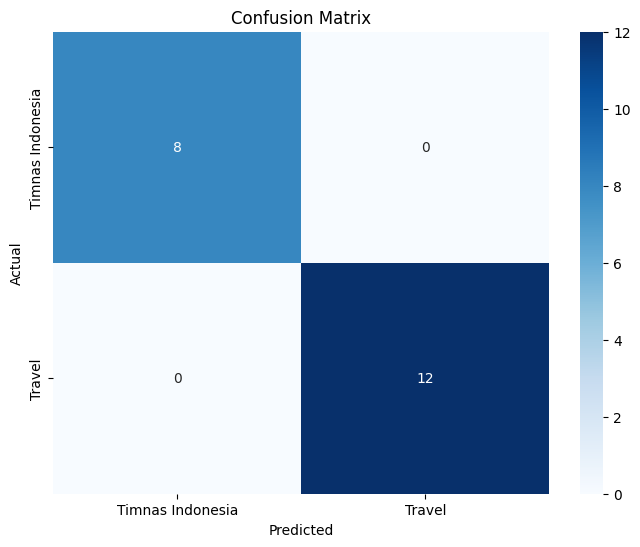

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Menentukan target (y)
y = df['kategori']  # Target adalah kategori berita

# Pisahkan dataset menjadi set pelatihan dan pengujian
X_train, X_test, y_train, y_test = train_test_split(svd_matrix, y, test_size=0.2, random_state=42)

# Inisialisasi model Regresi Logistik
model = LogisticRegression(max_iter=1000)

# Latih model
model.fit(X_train, y_train)

# Lakukan prediksi pada set pengujian
y_pred = model.predict(X_test)

# Evaluasi model
print("Confusion Matrix:")
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

print("\nHasil Klasifikasi:")
class_report = classification_report(y_test, y_pred, zero_division=0)
print(class_report)

# Menampilkan akurasi
accuracy = (y_pred == y_test).mean()
print(f"Akurasi Model: {accuracy:.2f}")

# Visualisasi Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()


DEPLOY : https://apptugas2withreduksidimensi.streamlit.app/
DEPLOY : https://huggingface.co/spaces/priob/tugas2withreduksi